# IND320 Project Work, Part 1

By: Katarzyna Haland

GitHub: [IND320-kahaland](https://github.com/kahalandkh/IND320-kahaland) \
Streamlit: \
Screencast:

## 0. Setup and imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Jupyter Notebook tasks

### 1.1 Read the `reservoirs.csv` file using Pandas

The dataset is stored in the repository's `data` folder.

The `dato_Id` column is parsed as a datetime variable when reading the CSV so that it can be used directly in later time-series visualisations.

In [2]:
# Read the reservoir dataset and interpret dato_Id as a date column
df = pd.read_csv("../data/reservoirs.csv", parse_dates=["dato_Id"])

# Check the imported data types
df.dtypes

dato_Id                     datetime64[us]
omrType                                str
omrnr                                int64
iso_aar                              int64
iso_uke                              int64
fyllingsgrad                       float64
kapasitet_TWh                      float64
fylling_TWh                        float64
neste_Publiseringsdato                 str
fyllingsgrad_forrige_uke           float64
endring_fyllingsgrad               float64
dtype: object

The output confirms that `dato_Id` has been imported as a datetime variable rather than as text. The DataFrame contains 11 columns in total, all of which have Norwegian names.

### 1.2 Rename headers to English and understandable names

The original column names are renamed to descriptive English names. Snake case is used for consistency and readability.

In [3]:
# Rename the original column headers to descriptive English names (Gemini 3.6 Flash was used to translate the Norwegian column headers to English)
df = df.rename(columns={"dato_Id": "date_id",
                        "omrType": "area_type",
                        "omrnr": "area_number",
                        "iso_aar": "iso_year",
                        "iso_uke": "iso_week",
                        "fyllingsgrad": "reservoir_fill_ratio",
                        "kapasitet_TWh": "reservoir_capacity_twh",
                        "fylling_TWh": "stored_energy_twh",
                        "neste_Publiseringsdato": "next_publication_date",
                        "fyllingsgrad_forrige_uke": "previous_week_reservoir_fill_ratio",
                        "endring_fyllingsgrad": "reservoir_fill_ratio_change"})

# Check the renamed column headers
df.columns

Index(['date_id', 'area_type', 'area_number', 'iso_year', 'iso_week',
       'reservoir_fill_ratio', 'reservoir_capacity_twh', 'stored_energy_twh',
       'next_publication_date', 'previous_week_reservoir_fill_ratio',
       'reservoir_fill_ratio_change'],
      dtype='str')

The output confirms that the column headers were renamed successfully.

### 1.3 Print the contents in a relevant way


#### 1.3.1 Initial overview
The dimensions, contents, and structure of the dataset are inspected to get an initial overview of the data.

In [4]:
# Check the number of rows and columns
df.shape

(14877, 11)

The dataset contains 14 877 rows and 11 columns, so displaying all rows would not provide a useful overview.

In [5]:
# Display the first 10 rows of the dataset
df.head(10)

,date_id,area_type,area_number,iso_year,iso_week,reservoir_fill_ratio,reservoir_capacity_twh,stored_energy_twh,next_publication_date,previous_week_reservoir_fill_ratio,reservoir_fill_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


The preview shows that the observations are not ordered chronologically by `date_id` (dates jump from `1995-09-03` to `2020-11-15` to `2011-08-28` to `1998-07-05`, etc.).

It also shows that `next_publication_date` contains several values equal to `0001-01-01T00:00:00`, which may represent missing or placeholder dates (these are investigated further in section 1.3.3).

In [6]:
# Inspect the DataFrame structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date_id                             14877 non-null  datetime64[us]
 1   area_type                           14877 non-null  str           
 2   area_number                         14877 non-null  int64         
 3   iso_year                            14877 non-null  int64         
 4   iso_week                            14877 non-null  int64         
 5   reservoir_fill_ratio                14877 non-null  float64       
 6   reservoir_capacity_twh              14877 non-null  float64       
 7   stored_energy_twh                   14877 non-null  float64       
 8   next_publication_date               14877 non-null  str           
 9   previous_week_reservoir_fill_ratio  14877 non-null  float64       
 10  reservoir_fill_ratio_change      

There are no null values detected in any of the columns. The output also shows that `next_publication_date` is stored as text.

In [7]:
# Display summary statistics for the numerical and datetime columns
df.describe()

,date_id,area_number,iso_year,iso_week,reservoir_fill_ratio,reservoir_capacity_twh,stored_energy_twh,previous_week_reservoir_fill_ratio,reservoir_fill_ratio_change
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385


The summary statistics show that the dataset covers dates from 1995 to 2026. The mean `reservoir_fill_ratio` is about 0.62, corresponding to roughly 62%. The maximum value is slightly above 1 (`1.020072`), indicating that some recorded fill ratios exceed 100%.

The numerical variables are measured on different scales. For example, the reservoir fill ratios are around 0-1, while the energy-related variables are measured in TWh and reach values of several tens of TWh. The `area_number` column ranges from 0 to 5 and it may represent categories rather than a continuous numerical variable. `iso_year` and `iso_week` are also integer-valued, but represent calendar information rather than physical measurements.

#### 1.3.2 Observations by date and area

In [8]:
# Check the frequency of values in the area number column
df["area_number"].value_counts().sort_index()

area_number
0    1653
1    3306
2    3306
3    3306
4    1653
5    1653
Name: count, dtype: int64

`area_number` contains six different values, from `0` to `5`. Values `1`, `2`, and `3` occur 3 306 times each, while `0`, `4`, and `5` occur 1 653 times each.

In [9]:
# Check the frequency of values in the area type column
df["area_type"].value_counts()

area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64

The `area_type` column contains three different string values: `EL`, `VASS`, and `NO`. `EL` is the most frequent with 8 265 observations, followed by `VASS` with 4 959 and `NO` with 1 653.

In [10]:
# Check how many observations occur for each date
df["date_id"].value_counts().value_counts().sort_index()

count
9    1653
Name: count, dtype: int64

The dataset contains 1 653 unique dates, with exactly nine observations recorded for each date.

In [11]:
# Inspect the unique combinations of area type and area number
df[["area_type", "area_number"]].drop_duplicates().sort_values(["area_type", "area_number"])

,area_type,area_number
1,EL,1
131,EL,2
3,EL,3
0,EL,4
9,EL,5
8265,NO,0
9924,VASS,1
9918,VASS,2
9919,VASS,3


There are nine unique combinations of `area_type` and `area_number`: five `EL` areas, three `VASS` areas, and one `NO` area. Since every date also occurs nine times, this suggests that each date contains one observation for each area combination.

In [12]:
# Check whether each date and area combination occurs only once
df.duplicated(subset=["date_id", "area_type", "area_number"]).sum()

np.int64(0)

Each combination of `date_id`, `area_type`, and `area_number` occurs only once.

#### 1.3.3 Investigation of `next_publication_date`

In [13]:
# Count how often the placeholder publication date occurs
(df["next_publication_date"] == "0001-01-01T00:00:00").sum()

np.int64(11322)

The value `0001-01-01T00:00:00` occurs 11 322 times in `next_publication_date`, meaning that it makes up the majority of the values in this column. To investigate whether these placeholder values follow a systematic pattern, their occurrence over time is examined below.

In [14]:
# Identify rows with an actual next publication date
has_publication_date = (df["next_publication_date"] != "0001-01-01T00:00:00")

# Check the date range for rows with actual publication dates
print(df.loc[has_publication_date, "date_id"].agg(["min", "max"]), end="\n\n")

# Check the latest date containing the placeholder value
print("Latest date with placeholder value:",
      df.loc[df["next_publication_date"] == "0001-01-01T00:00:00", "date_id"].max())

min   2019-02-17
max   2026-09-06
Name: date_id, dtype: datetime64[us]

Latest date with placeholder value: 2019-02-10 00:00:00


Actual values for `next_publication_date` occur from `2019-02-17` onward, while the latest observation containing the placeholder is dated `2019-02-10`. This clear one-week transition suggests that `next_publication_date` started being populated from `2019-02-17`, rather than the placeholder values being scattered randomly throughout the dataset.

In [15]:
# Check whether the publication-date status is the same for all areas on each date
print(df.assign(has_publication_date=has_publication_date).groupby("date_id")["has_publication_date"].nunique().value_counts(), end="\n\n")

# Check whether the actual next publication date is identical across areas
print(df.loc[has_publication_date].groupby("date_id")["next_publication_date"].nunique().value_counts())

has_publication_date
1    1653
Name: count, dtype: int64

next_publication_date
1    395
Name: count, dtype: int64


For each `date_id`, all area observations either contain an actual `next_publication_date` or the placeholder value. For the 395 dates with an actual `next_publication_date`, that date is identical across all areas. This suggests that `next_publication_date` is shared across all areas for a given date rather than being area-specific.

### 1.4 Plot each column separately

For time-series measurements, observations are grouped by `area_type` and `area_number` and sorted chronologically by `date_id` to avoid connecting measurements from different areas. Other columns are visualised using plot types appropriate to their contents.

#### 1.4.1 `date_id`

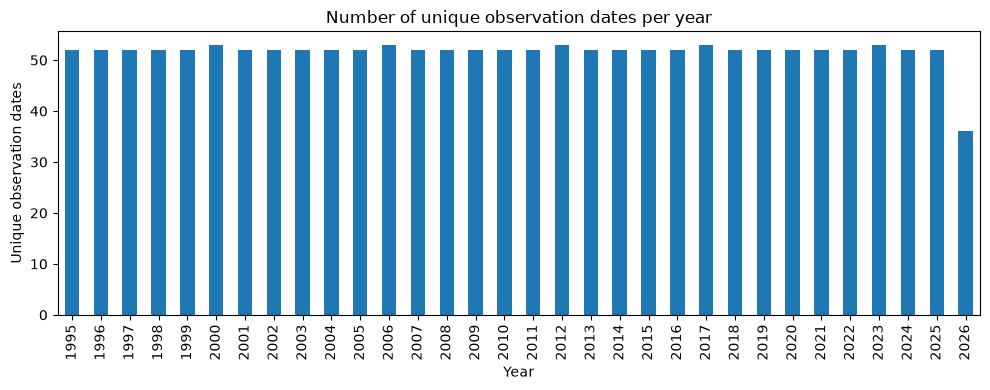

In [16]:
# Count the number of unique observation dates per year
dates_per_year = (df["date_id"].drop_duplicates().dt.year.value_counts().sort_index())

# Plot the temporal coverage of the dataset
plt.figure(figsize=(10, 4))
dates_per_year.plot(kind="bar")

plt.title("Number of unique observation dates per year")
plt.xlabel("Year")
plt.ylabel("Unique observation dates")
plt.tight_layout()
plt.show()

The dataset contains about 52–53 unique observation dates per year, which is consistent with weekly observations. The lower count in 2026 is because the dataset only extends to `2026-09-06`, so that year is incomplete.

#### 1.4.2 `area_type`

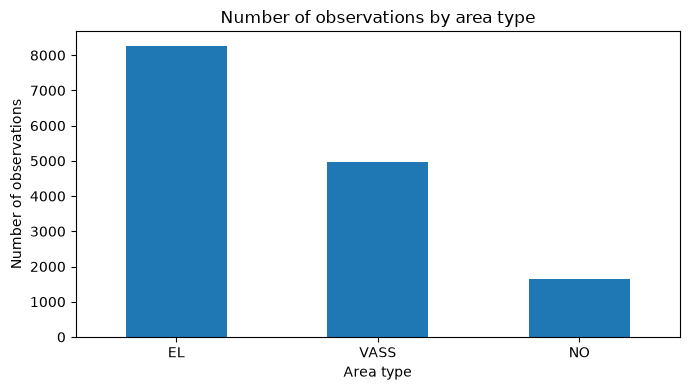

In [17]:
# Count observations for each area type
area_type_counts = df["area_type"].value_counts()

# Plot the frequency of each area type
plt.figure(figsize=(7, 4))
area_type_counts.plot(kind="bar")

plt.title("Number of observations by area type")
plt.xlabel("Area type")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

EL has the largest number of observations, followed by VASS and NO. This reflects the number of area combinations within each type: five for EL, three for VASS, and one for NO, with each combination represented for every observation date.

#### 1.4.3 `area_number`

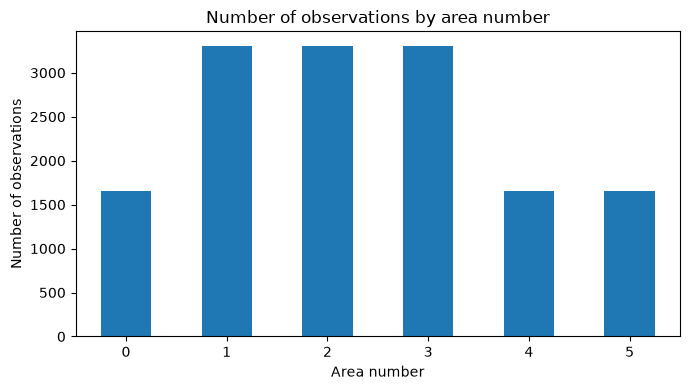

In [18]:
# Count observations for each area number
area_number_counts = df["area_number"].value_counts().sort_index()

# Plot the frequency of each area number
plt.figure(figsize=(7, 4))
area_number_counts.plot(kind="bar")

plt.title("Number of observations by area number")
plt.xlabel("Area number")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Area numbers `1`, `2`, and `3` occur about twice as often as `0`, `4`, and `5`. This is because area numbers `1`-`3` are used for both `EL` and `VASS`, while `0` occurs only for `NO` and `4`–`5` only for `EL`.

#### 1.4.4 `iso_year`

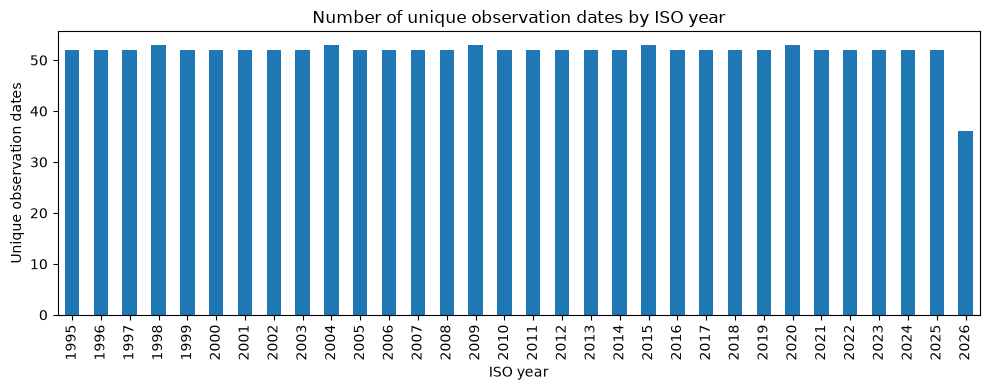

In [19]:
# Count unique observation dates for each ISO year
dates_per_iso_year = (df[["date_id", "iso_year"]].drop_duplicates()
                      ["iso_year"].value_counts().sort_index())

# Plot the number of unique observation dates by ISO year
plt.figure(figsize=(10, 4))
dates_per_iso_year.plot(kind="bar")

plt.title("Number of unique observation dates by ISO year")
plt.xlabel("ISO year")
plt.ylabel("Unique observation dates")
plt.tight_layout()
plt.show()

The distribution by `iso_year` is similar to the calendar-year distribution of `date_id`, as expected for weekly observations. Most ISO years contain 52 observation dates, while some contain 53. The lower count for 2026 is due to the dataset ending in September 2026.

#### 1.4.5 `iso_week`

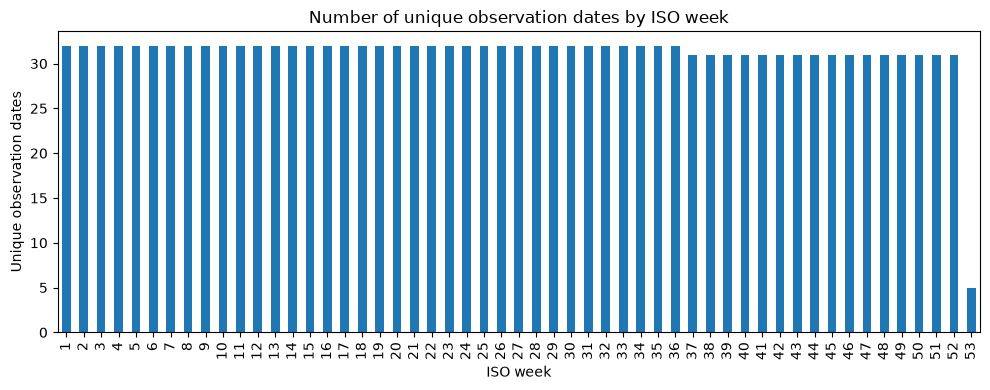

In [20]:
# Count unique observation dates for each ISO week
dates_per_iso_week = (df[["date_id", "iso_week"]].drop_duplicates()
                      ["iso_week"].value_counts().sort_index())

# Plot the number of unique observation dates by ISO week
plt.figure(figsize=(10, 4))
dates_per_iso_week.plot(kind="bar")

plt.title("Number of unique observation dates by ISO week")
plt.xlabel("ISO week")
plt.ylabel("Unique observation dates")
plt.tight_layout()
plt.show()

ISO weeks 1–36 occur 32 times, while weeks 37–52 occur 31 times. This reflects the fact that the dataset includes observations through ISO week 36 of 2026, so the remaining weeks of 2026 are not present. Week 53 occurs only five times because only some ISO years contain a 53rd week.

#### 1.4.6 `reservoir_fill_ratio`

To improve readability, the nine area-specific time series are divided into three subplots according to `area_type`. Within each subplot, the different `area_number` values are shown as separate lines. The subplots share the same axes to make comparisons between area types easier.

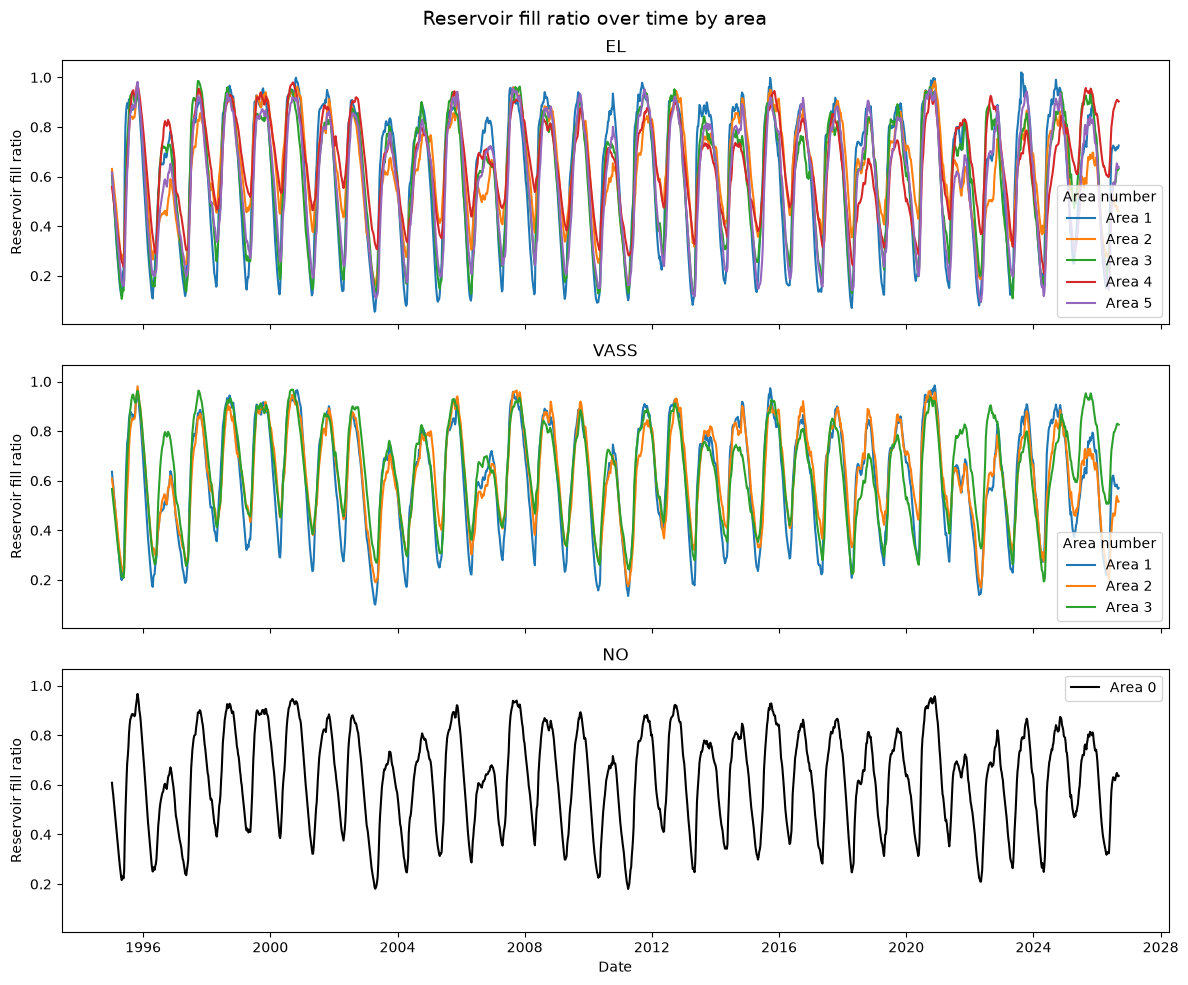

In [21]:
# Plot reservoir fill ratio over time by area type and area number
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

area_types = ["EL", "VASS", "NO"]

for ax, area_type in zip(axes, area_types):
    area_data = df[df["area_type"] == area_type]

    for area_number, group in area_data.groupby("area_number"):
        group = group.sort_values("date_id")

        if area_type == "NO":
            ax.plot(group["date_id"], group["reservoir_fill_ratio"],
                    label=f"Area {area_number}", color="black")
        else:
            ax.plot(group["date_id"], group["reservoir_fill_ratio"], 
                    label=f"Area {area_number}")

    ax.set_title(area_type)
    ax.set_ylabel("Reservoir fill ratio")

    if area_type == "NO":
        ax.legend()
    else:
        ax.legend(title="Area number")

axes[-1].set_xlabel("Date")

fig.suptitle("Reservoir fill ratio over time by area", fontsize=14)

plt.tight_layout()
plt.show()

The three subplots show a clear recurring seasonal pattern in `reservoir_fill_ratio` across all area types, although the magnitude of the fluctuations differs between individual areas.

#### 1.4.7 `reservoir_capacity_twh`

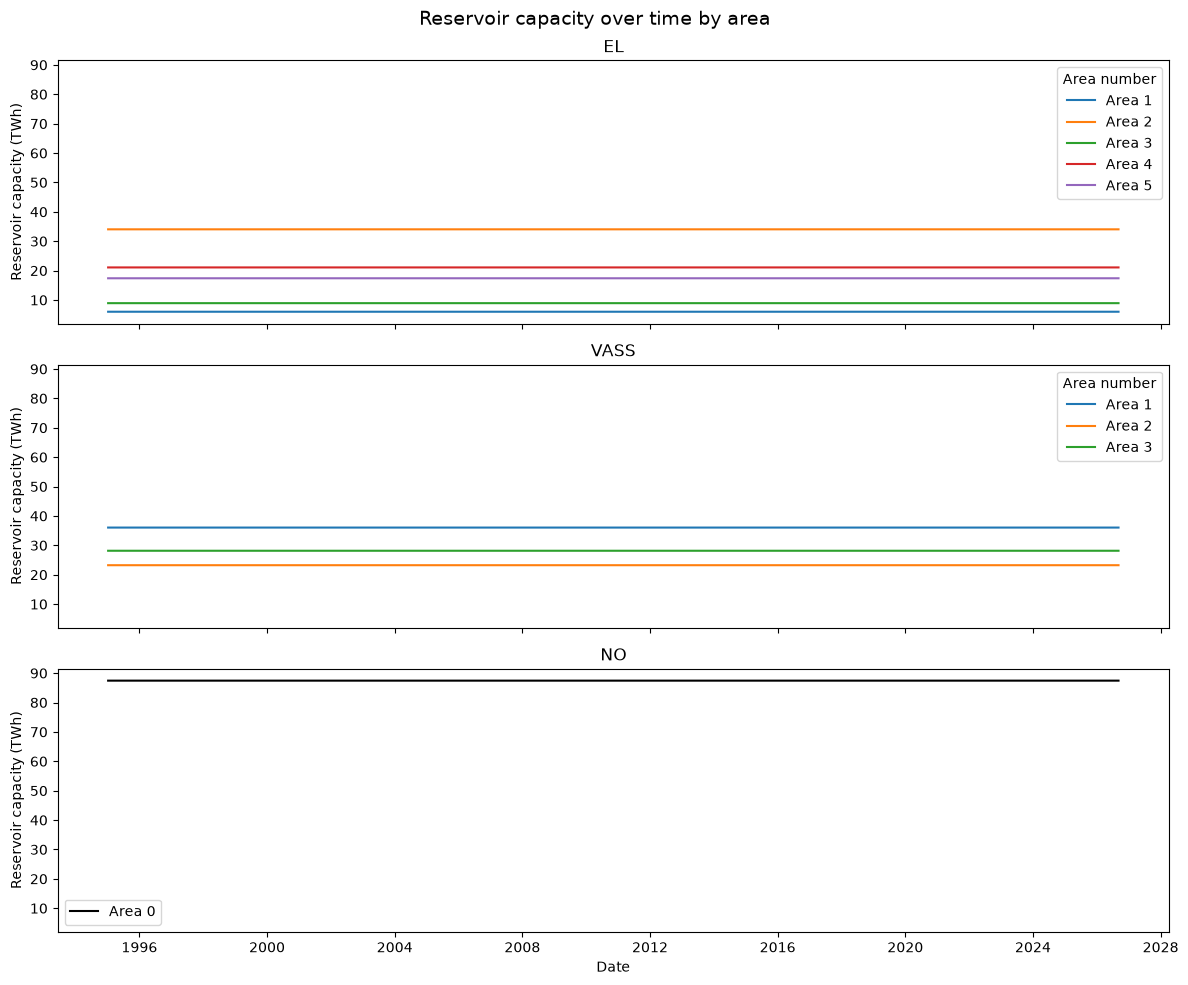

In [22]:
# Plot reservoir capacity over time by area type and area number
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

area_types = ["EL", "VASS", "NO"]

for ax, area_type in zip(axes, area_types):
    area_data = df[df["area_type"] == area_type]

    for area_number, group in area_data.groupby("area_number"):
        group = group.sort_values("date_id")

        if area_type == "NO":
            ax.plot(group["date_id"], group["reservoir_capacity_twh"],
                    label=f"Area {area_number}", color="black")
        else:
            ax.plot(group["date_id"], group["reservoir_capacity_twh"],
                    label=f"Area {area_number}")

    ax.set_title(area_type)
    ax.set_ylabel("Reservoir capacity (TWh)")

    if area_type == "NO":
        ax.legend()
    else:
        ax.legend(title="Area number")

axes[-1].set_xlabel("Date")

fig.suptitle("Reservoir capacity over time by area", fontsize=14)

plt.tight_layout()
plt.show()

`reservoir_capacity_twh` remains constant over time for each area. The different horizontal levels reflect different reservoir capacities across the area groups.

#### 1.4.8 `stored_energy_twh`

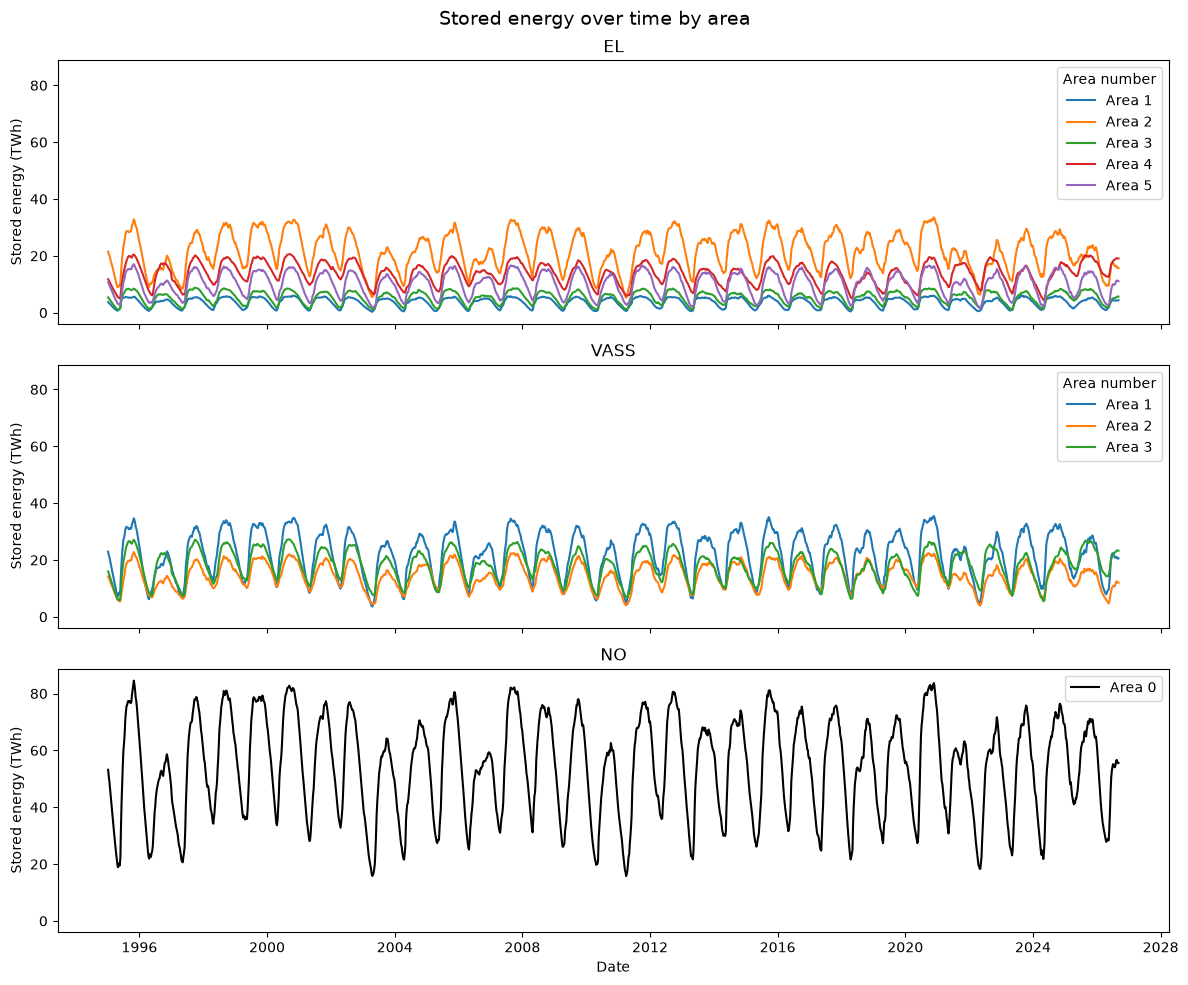

In [23]:
# Plot stored energy over time by area type and area number
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

area_types = ["EL", "VASS", "NO"]

for ax, area_type in zip(axes, area_types):
    area_data = df[df["area_type"] == area_type]

    for area_number, group in area_data.groupby("area_number"):
        group = group.sort_values("date_id")

        if area_type == "NO":
            ax.plot(group["date_id"], group["stored_energy_twh"],
                    label=f"Area {area_number}", color="black")
        else:
            ax.plot(group["date_id"], group["stored_energy_twh"],
                    label=f"Area {area_number}")

    ax.set_title(area_type)
    ax.set_ylabel("Stored energy (TWh)")

    if area_type == "NO":
        ax.legend()
    else:
        ax.legend(title="Area number")

axes[-1].set_xlabel("Date")

fig.suptitle("Stored energy over time by area", fontsize=14)

plt.tight_layout()
plt.show()

`stored_energy_twh` shows the same recurring seasonal pattern as `reservoir_fill_ratio`, but the absolute values differ substantially between areas because the reservoir capacities are different.

#### 1.4.9 `next_publication_date`

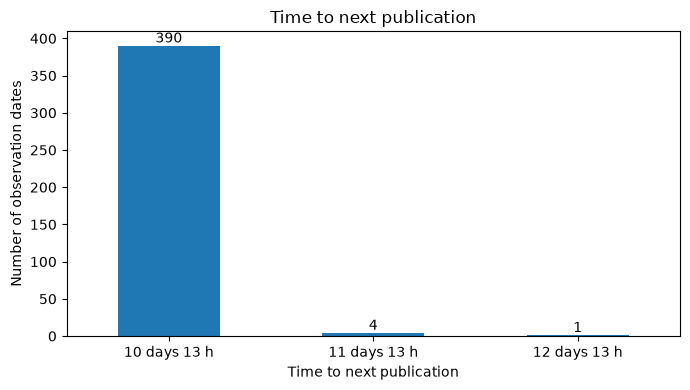

In [24]:
# Prepare one valid publication date for each observation date
publication_data = (df[df["next_publication_date"] != "0001-01-01T00:00:00"]
                    [["date_id", "next_publication_date"]].drop_duplicates().copy())

# Convert publication dates to datetime
publication_data["next_publication_date"] = pd.to_datetime(
    publication_data["next_publication_date"])

# Calculate the publication delay in whole hours
publication_data["publication_delay_hours"] = (
    publication_data["next_publication_date"] - publication_data["date_id"]
    ).dt.total_seconds().div(3600).round().astype(int)

# Create readable labels for the observed delays
publication_data["publication_delay"] = publication_data[
    "publication_delay_hours"].apply(
        lambda hours: f"{hours // 24} days {hours % 24} h")

# Count each publication delay
delay_counts = (publication_data.groupby(["publication_delay_hours", "publication_delay"])
                .size().sort_index())

# Plot the publication-delay frequencies
ax = delay_counts.plot(kind="bar", figsize=(7, 4))

plt.title("Time to next publication")
plt.xlabel("Time to next publication")
plt.ylabel("Number of observation dates")
plt.xticks(range(len(delay_counts)),
           [label for _, label in delay_counts.index], rotation=0)

# Display the exact count above each bar
for i, count in enumerate(delay_counts):
    ax.text(i, count, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()

For 390 of the 395 observation dates with an actual `next_publication_date`, the next publication occurs 10 days and 13 hours later. Only five observations have a longer interval, indicating a highly consistent publication schedule.

#### 1.4.10 `previous_week_reservoir_fill_ratio`

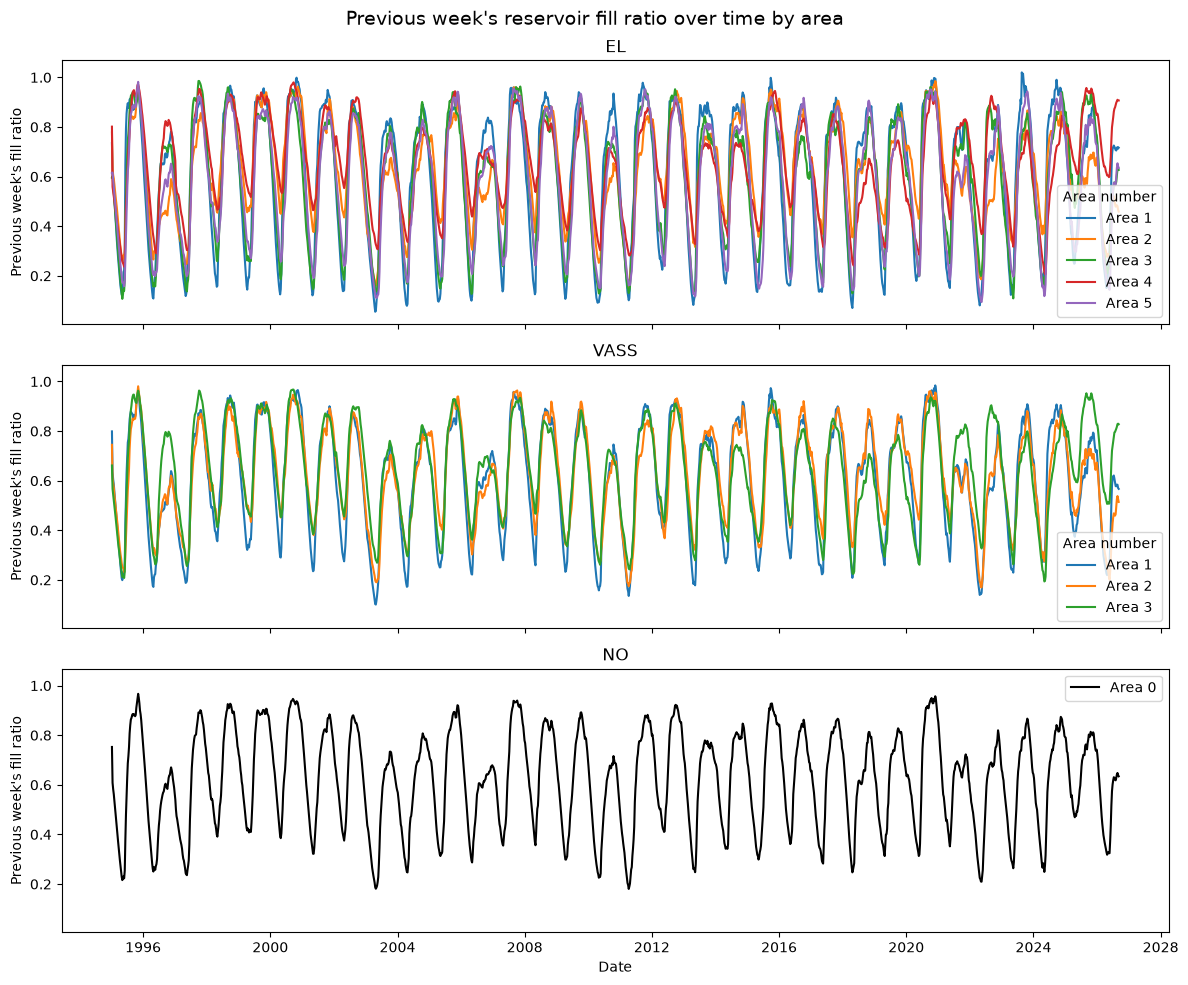

In [25]:
# Plot previous week's reservoir fill ratio over time by area type and area number
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

area_types = ["EL", "VASS", "NO"]

for ax, area_type in zip(axes, area_types):
    area_data = df[df["area_type"] == area_type]

    for area_number, group in area_data.groupby("area_number"):
        group = group.sort_values("date_id")

        if area_type == "NO":
            ax.plot(group["date_id"],
                    group["previous_week_reservoir_fill_ratio"],
                    label=f"Area {area_number}",
                    color="black")
        else:
            ax.plot(group["date_id"],
                    group["previous_week_reservoir_fill_ratio"],
                    label=f"Area {area_number}")

    ax.set_title(area_type)
    ax.set_ylabel("Previous week's fill ratio")

    if area_type == "NO":
        ax.legend()
    else:
        ax.legend(title="Area number")

axes[-1].set_xlabel("Date")

fig.suptitle("Previous week's reservoir fill ratio over time by area", fontsize=14)

plt.tight_layout()
plt.show()

`previous_week_reservoir_fill_ratio` shows the same seasonal pattern as `reservoir_fill_ratio`, as expected, since it represents the fill ratio from the preceding week.

#### 1.4.11 `reservoir_fill_ratio_change`

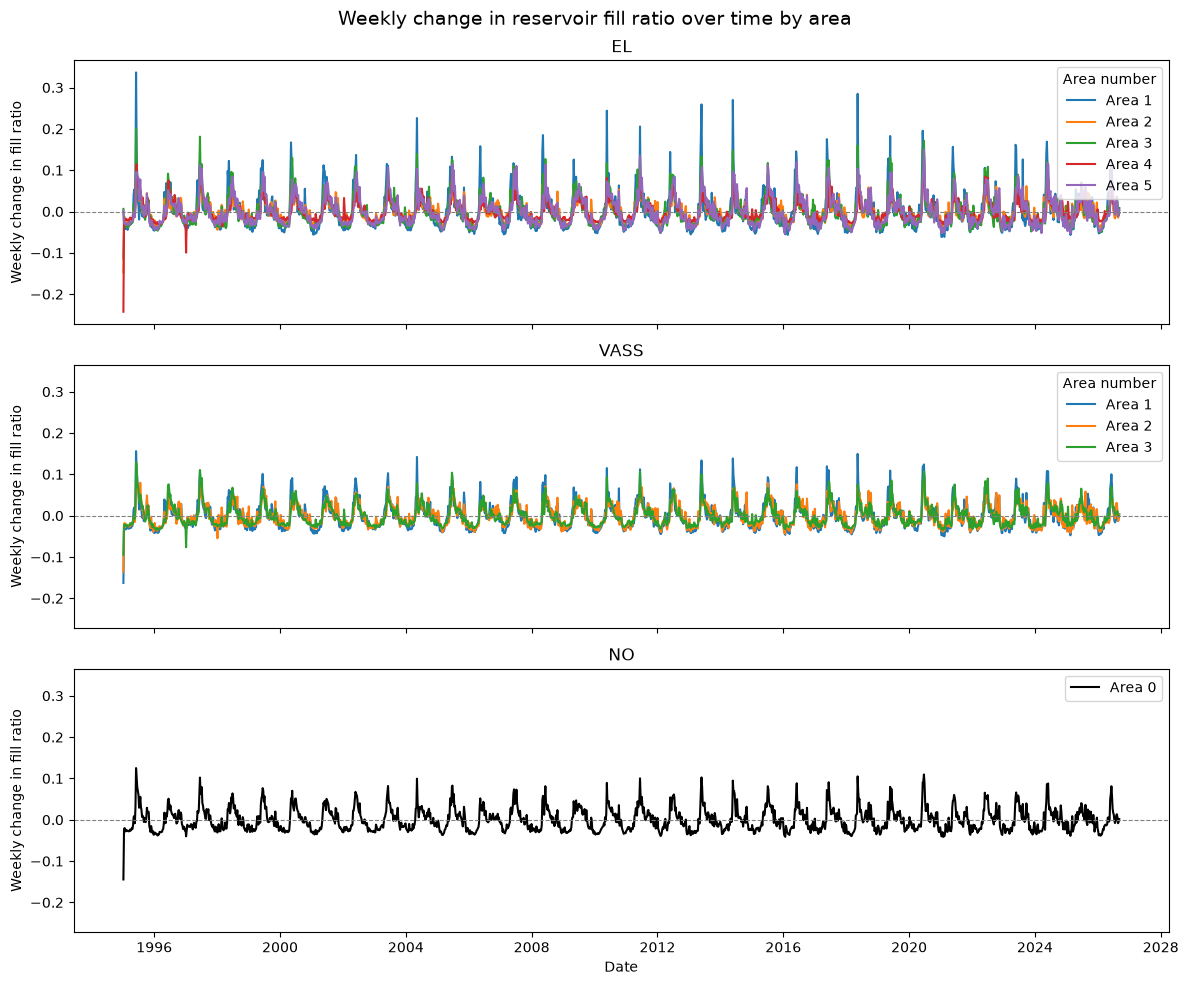

In [26]:
# Plot weekly change in reservoir fill ratio by area type and area number
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

area_types = ["EL", "VASS", "NO"]

for ax, area_type in zip(axes, area_types):
    area_data = df[df["area_type"] == area_type]

    for area_number, group in area_data.groupby("area_number"):
        group = group.sort_values("date_id")

        if area_type == "NO":
            ax.plot(group["date_id"], group["reservoir_fill_ratio_change"],
                    label=f"Area {area_number}", color="black")
        else:
            ax.plot(group["date_id"], group["reservoir_fill_ratio_change"],
                label=f"Area {area_number}")

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(area_type)
    ax.set_ylabel("Weekly change in fill ratio")

    if area_type == "NO":
        ax.legend()
    else:
        ax.legend(title="Area number")

axes[-1].set_xlabel("Date")

fig.suptitle("Weekly change in reservoir fill ratio over time by area", fontsize=14)

plt.tight_layout()
plt.show()

`reservoir_fill_ratio_change` fluctuates around zero across all area types, with recurring periods of positive and negative weekly changes. The largest individual changes occur in some of the `EL` areas.

### 1.5 Plot all columns together

Not all columns in the dataset represent measurements. `date_id` describes time, while `area_type` and `area_number` identify the individual area series. `iso_year`, `iso_week`, and `next_publication_date` contain additional date-related information.

The five reservoir measurement columns are therefore combined in the plot below. The fill-related variables are shown on the left y-axis, while `stored_energy_twh` and `reservoir_capacity_twh` are shown on the right y-axis because they are measured in TWh. The original values are retained without normalisation, and the two y-axes use separate scales.


<div class="alert alert-block alert-info">
<b>Plotting choice:</b> The <code>NO 0</code> series is used to keep the combined plot readable. An alternative would be to plot the combined measurements for all nine area combinations in a 3 × 3 subplot layout, but this would be more crowded and would largely repeat the area-specific visualisations in Section 1.4.
</div>

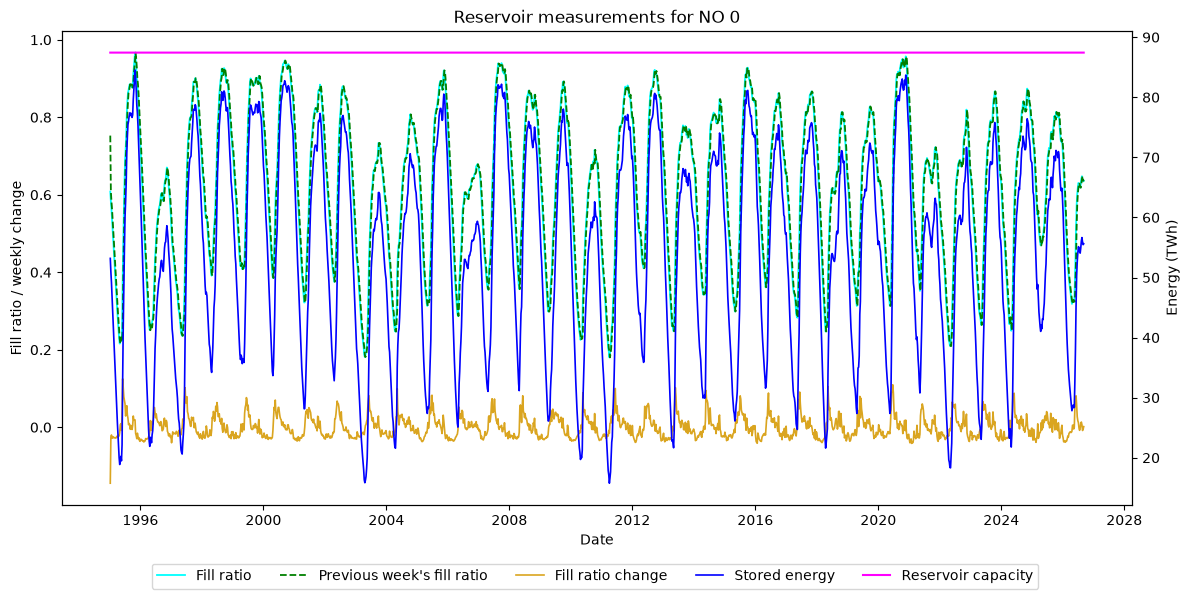

In [27]:
# Select the NO 0 time series and sort it chronologically
combined_data = (df[(df["area_type"] == "NO") & (df["area_number"] == 0)].sort_values("date_id"))

# Create a figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Fill-related variables: left y-axis
ax1.plot(combined_data["date_id"], combined_data["reservoir_fill_ratio"], label="Fill ratio",
         color="cyan", linewidth=1.3)

ax1.plot(combined_data["date_id"], combined_data["previous_week_reservoir_fill_ratio"],
         label="Previous week's fill ratio", color="green", linewidth=1.3, linestyle="--")

ax1.plot(combined_data["date_id"], combined_data["reservoir_fill_ratio_change"],
         label="Fill ratio change", color="goldenrod", linewidth=1.2)

# Energy-related variables: right y-axis
ax2.plot(combined_data["date_id"], combined_data["stored_energy_twh"],
         label="Stored energy", color="blue", linewidth=1.2)

ax2.plot(combined_data["date_id"], combined_data["reservoir_capacity_twh"],
         label="Reservoir capacity", color="magenta", linewidth=1.5)

# Title and axis labels
ax1.set_title("Reservoir measurements for NO 0")
ax1.set_xlabel("Date")
ax1.set_ylabel("Fill ratio / weekly change")
ax2.set_ylabel("Energy (TWh)")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(lines1 + lines2, labels1 + labels2, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.002), frameon=True)

# Leave space for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.show()

The combined plot shows that `reservoir_fill_ratio`, `previous_week_reservoir_fill_ratio`, and `stored_energy_twh` follow very similar patterns over time. For `NO 0`, `reservoir_capacity_twh` remains constant. `reservoir_fill_ratio_change` shows the change from the previous week's fill ratio, with positive values indicating an increase and negative values indicating a decrease.